In [50]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix ,classification_report 
import pickle

# 1. Load the data
df = pd.read_csv('factory_sensor_simulator_2040.csv')
df.head(3)

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2


In [51]:
cols_to_keep = [ 
    'Machine_Type', 
    'Temperature_C', 
    'Vibration_mms', 
    'Power_Consumption_kW', 
    'Remaining_Useful_Life_days', 
    'Failure_Within_7_Days'
]


In [52]:
new_df = df[cols_to_keep]
new_df.head(3)

,Machine_Type,Temperature_C,Vibration_mms,Power_Consumption_kW,Remaining_Useful_Life_days,Failure_Within_7_Days
0,Mixer,73.43,12.78,84.95,162.0,False
1,Industrial_Chiller,58.32,14.99,154.61,147.0,False
2,Pick_and_Place,49.63,23.78,51.90,0.0,True


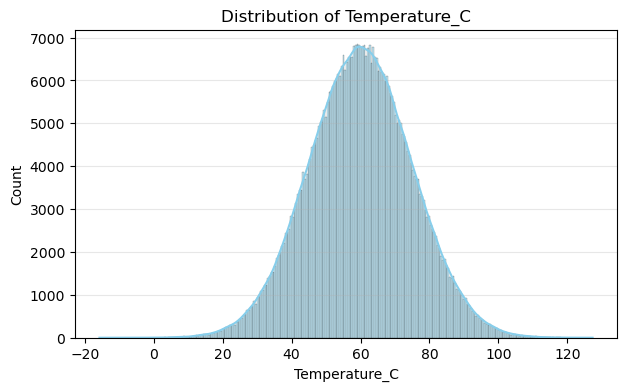

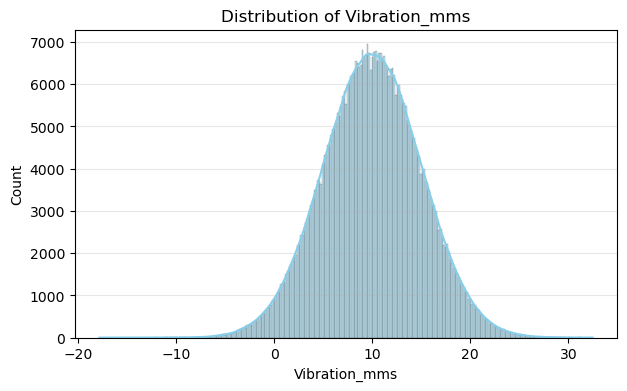

In [53]:
# 3. Define the plotting function
def plot_histogram(df_input, column_name):
    plt.figure(figsize=(7, 4))
    sns.histplot(df_input[column_name], kde=True, color='skyblue')
    plt.title(f"Distribution of {column_name}")
    plt.xlabel(column_name)
    plt.ylabel("Count")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Generate the plots
plot_histogram(new_df, "Temperature_C")
plot_histogram(new_df, "Vibration_mms")

In [54]:
#Correct the Boolean mapping (False -> 0, True -> 1)
new_df["Failure_Within_7_Days"] = new_df["Failure_Within_7_Days"].astype(int)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17440\2207020625.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["Failure_Within_7_Days"] = new_df["Failure_Within_7_Days"].astype(int)


In [55]:
object_columns = new_df.select_dtypes(include="object").columns
print(f"Columns to be encoded: {list(object_columns)}")

Columns to be encoded: ['Machine_Type']


In [56]:
# Initialize dictionary to save encoders
encoders = {}

# Apply label encoding
for column in object_columns:
    le = LabelEncoder()
    new_df[column] = le.fit_transform(new_df[column])
    encoders[column] = le


C:\Users\Admin\AppData\Local\Temp\ipykernel_17440\4281235303.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[column] = le.fit_transform(new_df[column])


In [57]:
# 1. Define Features (X) and Target (y)
X = new_df.drop(['Remaining_Useful_Life_days', 'Temperature_C',	'Vibration_mms'], axis=1)
y = new_df['Failure_Within_7_Days']

In [58]:
# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y_train.value_counts())

Failure_Within_7_Days
0    375928
1     24072
Name: count, dtype: int64


In [59]:
# 3. Initialize and Train the Model
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
# Handle class imbalance (since failures are rare)  oversampled it
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Train XGBoost Model
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

print(y_resampled.value_counts())


Failure_Within_7_Days
0    469968
1    469968
Name: count, dtype: int64


In [66]:
# 3. MODEL DEFINITIONS
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}


# Save model and encoder for the predictive system
with open('pdm_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('encoder_pdm.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Training complete. Model and Encoder saved.")


Training complete. Model and Encoder saved.


Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93791
           1       1.00      1.00      1.00     94197

    accuracy                           1.00    187988
   macro avg       1.00      1.00      1.00    187988
weighted avg       1.00      1.00      1.00    187988



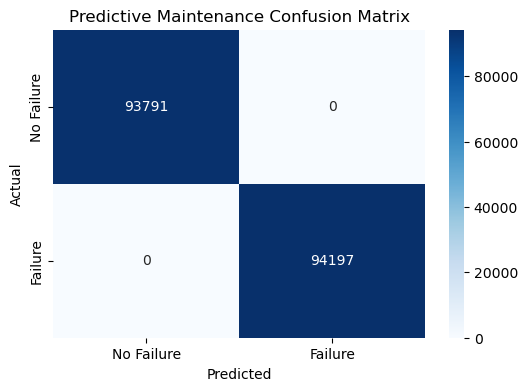

In [67]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Print metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Predictive Maintenance Confusion Matrix')
plt.show()

In [68]:
#Load Model and Build Predictive System

def maintenance_predictive_system(m_type, temp, vib, power):
    # 1. Load the saved components
    with open('pdm_model.pkl', 'rb') as f:
        loaded_model = pickle.load(f)
    with open('encoder.pkl', 'rb') as f:
        loaded_encoder = pickle.load(f)
    
    # 2. Preprocess the new input
    try:
        m_type_encoded = loaded_encoder.transform([m_type])[0]
    except ValueError:
        print(f"Warning: {m_type} is a new machine type. Result may be less accurate.")
        m_type_encoded = 0 # Default fallback
        
    input_features = np.array([[m_type_encoded, temp, vib, power]])
    
    # 3. Generate Prediction
    prediction = loaded_model.predict(input_features)[0]
    probability = loaded_model.predict_proba(input_features)[0][1]
    
    # 4. Output Result
    if prediction == 1:
        return f"ALERT: High Risk of Failure Detected! (Prob: {probability:.2%})"
    else:
        return f"System Stable. No immediate failure predicted. (Prob: {probability:.2%})"